### Лабораторная работа 4. СМО (Система массового обслуживания)
Имеется n-канальная СМО с неограниченной очередью. На ее вход поступает простейший поток заявок с интенсивностью X; время обслуживания — показательное с параметром Х. Обслуживание происходит без гарантии качества; с вероятностью р оно удовлетворяет заявку, а с вероятностью q = 1 — р — не удовлетворяет, и заявка обращается в СМО вторично и либо сразу обслуживается, если нет очереди, либо становится в очередь, если она есть. Ввести состояния СМО (нумеруя их по числу заявок в СМО); найти финальные вероятности состояний и характеристики эффективности СМО. Найти среднее число рекламаций, поданных в единицу времени, если каждая неудачно обслуженная заявка подает рекламацию с вероятностью R.

Интенсивность: $\lambda$ = X  <br>
Время обслуживания - показательное с параметром X. <br>$\mu$ = X => среднее время обслуживания равно 1 / X

## Решение
$s_0$ - СМО свободна <br/>
$s_1$ - занят один канал <br/>
$s_k$ - занято k каналов (1 <= k <= n) <br/>
$s_n$ - заняты все n каналов <br/>
$s_{n+r}$ - заняты все n каналов, а r заявок стоит в очереди <br/>
Граф состояний приведен ниже <br/>
![](image_copy.png) <br/>
где эффективная интенсивность потока $\widetilde{\mu} = p\mu$ = pX <br/>
Тогда $\widetilde{p}$ = $\lambda$ / $\widetilde{\mu}$ = $\lambda$ / $p\mu$ = X / pX = 1 / p <br/>
Условие установления предельного стационарного режима: $\widetilde{p}$ <= n (выберем значение n подходящим под данное условие)

##  Финальные вероятности состояний
Финальные вероятности состояний выражаются следующими формулами
![](final_probabilities.png)
<br/> $\widetilde{p}$ = 1 / p <br/> $\chi$ = $\widetilde{p}$ / n = 1 / np

Показательное распределение (экспоненциальное распределение) описывает время между независимыми событиями, которые происходят с постоянной средней частотой (интенсивностью).

Пример. Пусть есть магазин, в который время от времени заходят покупатели. При определённых допущениях время между появлениями двух последовательных покупателей будет случайной величиной с экспоненциальным распределением. Среднее время ожидания нового покупателя равно 1/λ
Сам параметр λ тогда может быть интерпретирован как среднее число новых покупателей за единицу времени.

### Найдем вероятности состояния системы:



In [1]:
import math

p = 0.7                 
n = 10                   
X = 30                   
Y = 10                   
p_tilde = X / (p* Y)   
chi = p_tilde / n       

def p_0(p_tilde, chi, n):

    result = 1
    for i in range(1, n + 1):
        result += (p_tilde ** i / math.factorial(i))
    result += (p_tilde ** (n + 1) / (n * math.factorial(n))) * (1 / (1 - chi))
    return 1 / result
    
def p_k(p_tilde, k, p_0):

    return p_tilde ** k * p_0 / math.factorial(k)

def p_n_r(p_tilde, n, r, p_0):

    return p_tilde ** (n + r) * p_0 / (n ** r * math.factorial(n))
    

def calculate_probabilities(p_tilde, chi, n, size):

    if(size < n):
        print('Размер должен быть > n')
        return
    p_list = []
    _p_0 = p_0(p_tilde, chi, n)
    p_list.append(_p_0)
    for k in range(1, n + 1):
        p_list.append(p_k(p_tilde, k, _p_0))
    for r in range(1, size - n + 1):
        p_list.append(p_n_r(p_tilde, n, r, _p_0))
    return p_list

Проверяем выполнение условия установления стационарного режима в системе массового обслуживания (СМО) и выводим вероятности состояний, если условие выполнено.
Здесь проверяется, что chi (загрузка системы) не превышает 1. Это важно, потому что если загрузка системы больше 1, система находится в нестабильном состоянии (число заявок в очереди бесконечно растет). Если chi <= 1, то система может работать в стационарном режиме.

In [2]:
size = 12
p_list = []
print(f'chi {chi}')
if chi <= 1:
    p_list = calculate_probabilities(p_tilde, chi, n, size)
    for i in range(size):
        print(f'p[{i}] :  {p_list[i]}')
    print(f'sum : {sum(p_list)}')
else:
    print('Условие установления предельного страционарного режима не выполнено')

chi 0.42857142857142855
p[0] :  0.013746795732046894
p[1] :  0.05891483885162955
p[2] :  0.12624608325349188
p[3] :  0.1803515475049884
p[4] :  0.19323380089820183
p[5] :  0.1656289721984587
p[6] :  0.11830640871318479
p[7] :  0.07243249513052132
p[8] :  0.0388031223913507
p[9] :  0.018477677329214615
p[10] :  0.007919004569663407
p[11] :  0.003393859101284317
sum : 0.998909116717444


##  Характеристики эффективности СМО

Среднее число ожидающих заявок
<br/>
![](moz.png)
<br/>
Среднее число заявок в системе
<br/>
![](m.png)

Вычисления различных характеристик эффективности работы системы массового обслуживания (СМО) с неограниченной очередью

In [3]:
def m_waiting(n, p_list):

    m = 0
    for i in range(n + 1, len(p_list)):
        m += i * p_list[i]
    return m
        
def m_all(n, p_list):

    m = 0
    for i in range(len(p_list)):
        m += i * p_list[i]
    return m

def mean_busy_channels(n, p_list):

    m = 0
    for i in range(n + 1):
        m += i * p_list[i]
    for i in range(n + 1, len(p_list)):
        m += n * p_list[i]
    return m

def mean_free_channels(n, p_list):

    return n - mean_busy_channels(n, p_list)

print('Вероятность отказа: P(отк) = 0, т.к. неограниченная очередь')
print('Среднее число заявок в очереди: ', m_waiting(n, p_list))
print('Среднее число заявок в системе: ', m_all(n, p_list))
print('Среднее число заявок в обслуживании : ', m_all(n, p_list) - m_waiting(n, p_list))
print()
print('Среднее число занятых каналов: ', mean_busy_channels(n, p_list))
print('Среднее число свободных каналов: ', mean_free_channels(n, p_list))
print('Коэффициент загрузки: ', mean_busy_channels(n, p_list) / n)
print('Коэффициент простоя: ', mean_free_channels(n, p_list) / n)

Вероятность отказа: P(отк) = 0, т.к. неограниченная очередь
Среднее число заявок в очереди:  0.05478658263501826
Среднее число заявок в системе:  4.281108334076827
Среднее число заявок в обслуживании :  4.226321751441809

Среднее число занятых каналов:  4.274805452888727
Среднее число свободных каналов:  5.725194547111273
Коэффициент загрузки:  0.4274805452888727
Коэффициент простоя:  0.5725194547111273


#### Среднее время ожидания в системе

In [4]:
mean_t = 1 / X
print('Среднее время обслуживания заявки: ', mean_t)
print('Среднее время нахождения в очереди: ', mean_t * m_waiting(n, p_list))
print('Среднее время нахождения в системе: ', mean_t + mean_t * m_waiting(n, p_list))

Среднее время обслуживания заявки:  0.03333333333333333
Среднее время нахождения в очереди:  0.0018262194211672753
Среднее время нахождения в системе:  0.03515955275450061


##  Среднее число рекламаций

In [5]:
complaint_rate = 0.3
mean_current_claims = m_all(n, p_list) - m_waiting(n, p_list)
mean_complaint_number = mean_current_claims * (1 - p) * complaint_rate
print('Среднее число рекламаций за единицу времени: ', mean_complaint_number)

Среднее число рекламаций за единицу времени:  0.3803689576297628


##  Моделирование СМО

In [6]:
import random
import numpy as np


class Claim:
    def __init__(self):
        self.time_in_system = 0
        self.time_in_queue = 0
        self.time_in_processing = 0
        self.complaint_number = 0


class Channel:
    def __init__(self):
        self.is_free = True          
        self.time_to_solve_remaining = 0


class QueuingSystemGenerator: 
    def __init__(self, n, probability, X, Y, R, size_of_probabilities):
        self.probability = probability   
        self.n = n                   
        self.channels = [Channel() for i in range(n)]
        self.claims = []                 
        self.X = X                       
        self.Y = Y                       
        self.time_discreteness = 100        
        self.time_step = 1 / self.time_discreteness
        self.processedClaims = []           
        self.complaint_prob = R            
        self.size_of_probabilities = size_of_probabilities
        self.channel_probabilities = [0 for i in range(size_of_probabilities)]
  
    def rand_is_claim_accepted(self):
        return random.random() < self.probability
    
    def rand_claim_resolve_time(self):
        return np.random.exponential(1 / self.Y)

    def rand_new_claim_comming(self):
        return random.random() < self.X / self.time_discreteness

    def rand_is_complaint(self):
        return random.random() < self.complaint_prob

    def busy_channels_count(self):
        count = 0
        for i in range(len(self.channels)):
            if not self.channels[i].is_free:
                count += 1
        return count
    
    def simulate_coming_claims(self):
        has_come = self.rand_new_claim_comming()
        if has_come:
            self.claims.append(Claim())
    
    def simulate_claim_to_free_channels(self):
        for i in range(len(self.channels)):
            if self.channels[i].is_free:
                if len(self.claims) == 0:
                    break
                self.channels[i].solving_claim = self.claims.pop()
                self.channels[i].is_free = False
                self.channels[i].time_to_solve_remaining += self.rand_claim_resolve_time()

    def simulate_process_claims(self):
        for i in range(len(self.claims)):
            self.claims[i].time_in_queue += self.time_step
        
        for i in range(len(self.channels)):
            if not self.channels[i].is_free:
                claim = self.channels[i].solving_claim
                if self.channels[i].time_to_solve_remaining > 0:
                    self.channels[i].time_to_solve_remaining -= self.time_step
                    claim.time_in_processing += self.time_step
                else:
                    self.channels[i].is_free = True
                    self.channels[i].time_to_solve_remaining = 0
                    is_claim_accepted = self.rand_is_claim_accepted()
                    if is_claim_accepted:
                        self.processedClaims.append(claim)
                    else:
                        self.claims.append(claim)
                        if self.rand_is_complaint():
                            claim.complaint_number += 1
    
    def next_time_step(self):
        self.simulate_coming_claims()
        self.simulate_claim_to_free_channels()
        self.simulate_process_claims()
    
    def run_simulation(self, time_units):
        avg_busy_channels = 0
        for i in range(time_units * self.time_discreteness):
            self.next_time_step()
            busy_channels = self.busy_channels_count()
            avg_busy_channels = (avg_busy_channels * i + busy_channels) / (i + 1)
            
            if busy_channels == self.n:
                claims_in_queue = len(self.claims)
                busy_channels += claims_in_queue
            if busy_channels < self.size_of_probabilities:
                self.channel_probabilities[busy_channels] += 1
        
        print('Среднее количество занятых каналов: ', avg_busy_channels)

        self.channel_probabilities = [self.channel_probabilities[i] / (time_units * self.time_discreteness) for i in range(len(self.channel_probabilities))]
        return self.channel_probabilities

In [7]:
R = 0.3
size_of_probabilities = 13

generator = QueuingSystemGenerator(n, p, X, Y, R, size_of_probabilities)
channel_probabilities = generator.run_simulation(5000)

Среднее количество занятых каналов:  4.511171999999919


### Сравнение аналитических результатов и симуляции

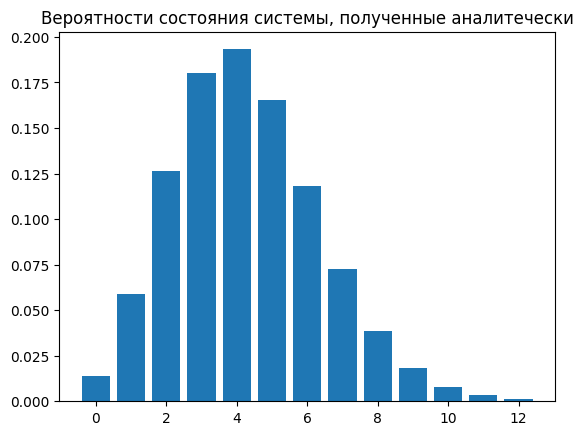

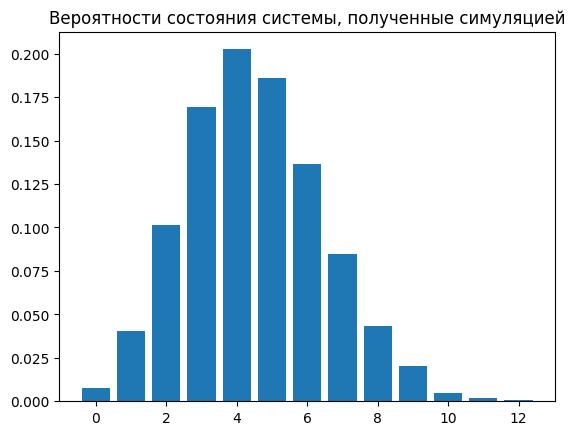

[0.007608, 0.040404, 0.101656, 0.169222, 0.202514, 0.186004, 0.136392, 0.084476, 0.043328, 0.020554, 0.00499, 0.001692, 0.000666]


In [8]:
import matplotlib.pyplot as plt

plt.bar(range(len(p_list)), p_list)
plt.title('Вероятности состояния системы, полученные аналитечески')
plt.show()

plt.bar(range(len(channel_probabilities)), channel_probabilities)
plt.title('Вероятности состояния системы, полученные симуляцией')
plt.show()
print(channel_probabilities)